In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Load all saved results
with open('results_baseline.pkl', 'rb') as f:
    baseline = pickle.load(f)
with open('results_h1.pkl', 'rb') as f:
    h1 = pickle.load(f)
with open('results_h2.pkl', 'rb') as f:
    h2 = pickle.load(f)
with open('results_h3_lr01.pkl', 'rb') as f:
    h3_lr01 = pickle.load(f)
with open('results_h3_lr0001.pkl', 'rb') as f:
    h3_lr0001 = pickle.load(f)
with open('results_final.pkl', 'rb') as f:
    final = pickle.load(f)

print("All results loaded.")

All results loaded.


In [2]:
# Comparison table of all experiments
print(f"{'Configuration':<45} {'Best Val Accuracy':>18}")
print("-" * 64)
print(f"{'Baseline (frozen, no aug, lr=0.001)':<45} {baseline['best_val_acc']:>18.4f}")
print(f"{'Exp 1: unfrozen backbone':<45} {h1['best_val_acc']:>18.4f}")
print(f"{'Exp 2: unfrozen + data augmentation':<45} {h2['best_val_acc']:>18.4f}")
print(f"{'Exp 3a: same as Exp 2 but lr=0.01':<45} {h3_lr01['best_val_acc']:>18.4f}")
print(f"{'Exp 3b: same as Exp 2 but lr=0.0001':<45} {h3_lr0001['best_val_acc']:>18.4f}")
print("-" * 64)
print(f"\nFinal model (Exp 2 config, retrained on full trainval)")
print(f"  Overall test accuracy:      {final['test_accuracy']:.4f}")
print(f"  Average per-class accuracy: {final['avg_per_class_accuracy']:.4f}")

Configuration                                  Best Val Accuracy
----------------------------------------------------------------
Baseline (frozen, no aug, lr=0.001)                       0.5393
Exp 1: unfrozen backbone                                  0.7940
Exp 2: unfrozen + data augmentation                       0.8315
Exp 3a: same as Exp 2 but lr=0.01                         0.7004
Exp 3b: same as Exp 2 but lr=0.0001                       0.4082
----------------------------------------------------------------

Final model (Exp 2 config, retrained on full trainval)
  Overall test accuracy:      0.8819
  Average per-class accuracy: 0.8820


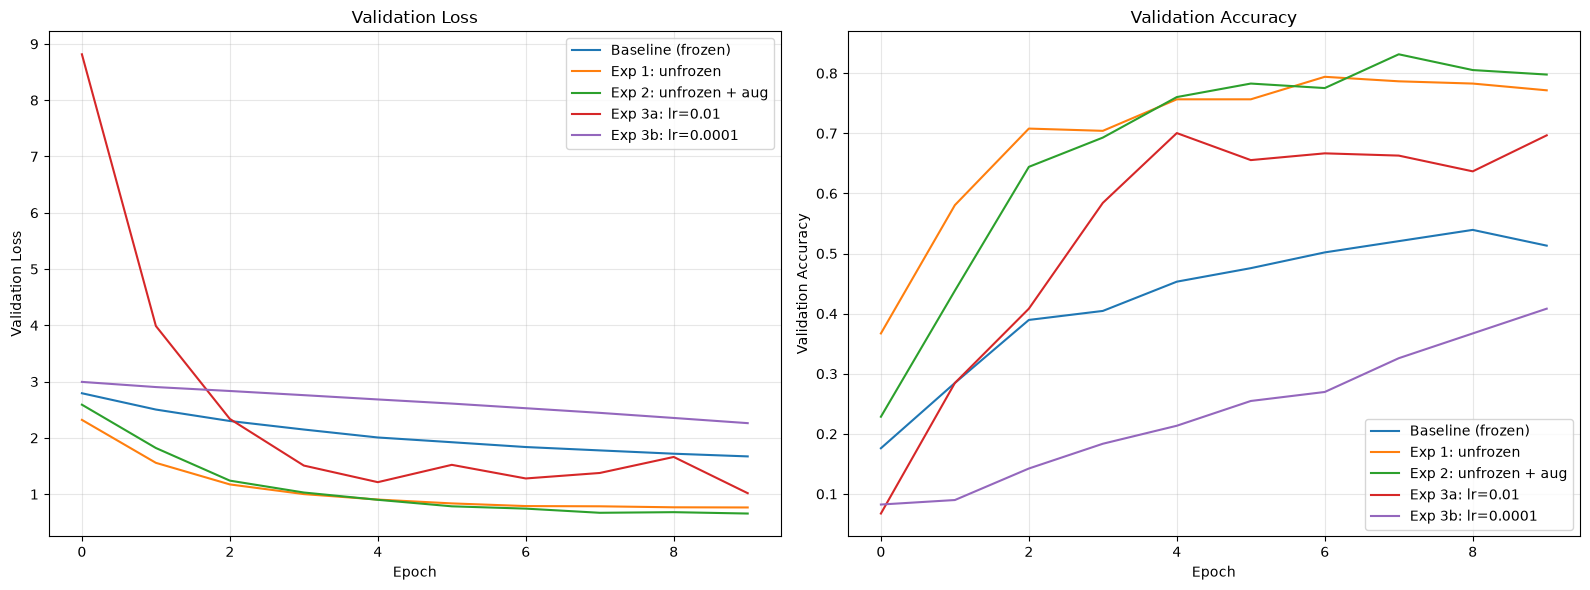

In [3]:
# Learning curves for all experiments on a single graph, as required by the brief
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

runs = [
    (baseline,   'Baseline (frozen)'),
    (h1,         'Exp 1: unfrozen'),
    (h2,         'Exp 2: unfrozen + aug'),
    (h3_lr01,    'Exp 3a: lr=0.01'),
    (h3_lr0001,  'Exp 3b: lr=0.0001'),
]

for run, label in runs:
    axes[0].plot(run['val_loss'], label=label)
    axes[1].plot(run['val_acc'], label=label)

axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Validation Loss')
axes[0].set_title('Validation Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Validation Accuracy')
axes[1].set_title('Validation Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

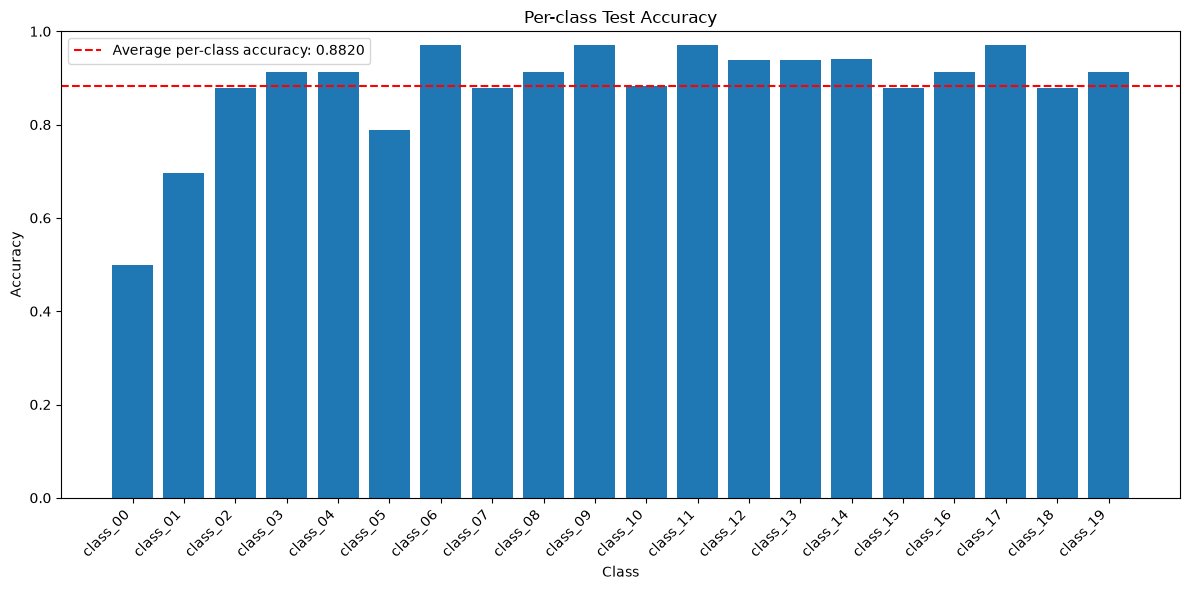

Worst class: class_00 (0.5000)
Best class:  class_06 (0.9706)


In [4]:
class_names = [f'class_{i:02d}' for i in range(20)]
class_accuracies = final['class_accuracies']
avg = final['avg_per_class_accuracy']

plt.figure(figsize=(12, 6))
plt.bar(range(len(class_accuracies)), class_accuracies)
plt.xticks(range(len(class_accuracies)), class_names, rotation=45, ha='right')
plt.xlabel('Class'); plt.ylabel('Accuracy'); plt.title('Per-class Test Accuracy')
plt.ylim([0, 1])
plt.axhline(y=avg, color='r', linestyle='--', label=f'Average per-class accuracy: {avg:.4f}')
plt.legend(); plt.tight_layout(); plt.show()

print(f"Worst class: {class_names[int(np.argmin(class_accuracies))]} ({np.min(class_accuracies):.4f})")
print(f"Best class:  {class_names[int(np.argmax(class_accuracies))]} ({np.max(class_accuracies):.4f})")

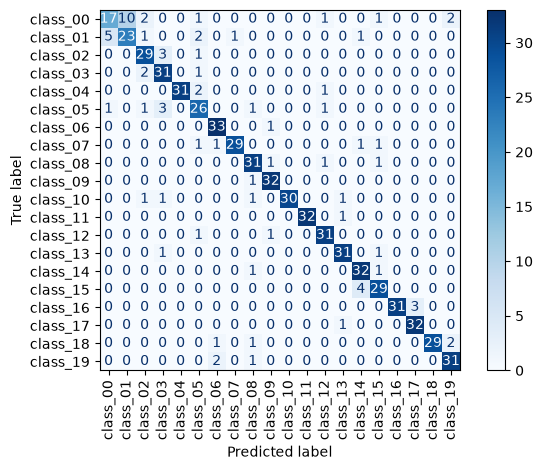

In [5]:
disp = ConfusionMatrixDisplay.from_predictions(final['all_labels'], final['all_predictions'],
                                               display_labels=class_names,
                                               cmap=plt.cm.Blues, xticks_rotation='vertical')
plt.tight_layout()
plt.show()